In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from confidenceinterval import  f1_score, precision_score, recall_score
import numpy as np  
import json
import textwrap

In [2]:
fs_gen_dir = "../../../data/llm_performance/fs/gens/prag"
print(os.listdir(fs_gen_dir))
ft_gen_dir = "../../../open-instruct/inference/gens/prag"
print(os.listdir(ft_gen_dir))
train_test_dir = "../../../data/llm_performance/ft/train_test"
print(os.listdir(train_test_dir))
data_dir = "../../../data/llm_performance/annotation_stuff"
print(os.listdir(data_dir))

['pragmatic_claude_fewshot_responses.json', 'pragmatic_claude_responses.json', 'pragmatic_gemini_fewshot_responses.json', 'pragmatic_gemini_responses.json', 'pragmatic_gpt5_fewshot_responses.json', 'pragmatic_gpt5_responses.json', 'pragmatic_gemini-3_fewshot_responses.json', 'pragmatic_claude-45_fewshot_responses.json', 'pragmatic_gpt51_fewshot_responses.json', 'pragmatic_claude-45_responses.json', 'pragmatic_gemini-3_responses.json']
['olmo2-7b-instruct_qlora_prag_2e4_res.json', 'qwen3-8b_qlora_prag_2e4_res.json', 'llama-3.1-8b-instruct_qlora_prag_2e4_res.json', 'gpt4-ft_prag_res.json', 'gemini-ft_prag_test_raw.jsonl', 'gemini-ft_prag_res.json', 'random_prag_res.json']
['novelty_train.jsonl', 'novelty_test.jsonl', 'nov_train_id2para.json', 'prag_train.jsonl', 'old', 'prag_test_id2para.json', 'prag_train_id2para.json', 'nov_test_id2para.json', 'prag_test.jsonl']
['all_nfront_passages.csv', 'all_novel_expressions.csv', 'all_novel_nfront_expressions.csv', 'all_passages.csv', 'all_frontie

In [3]:
with open(f"{train_test_dir}/prag_train_id2para.json", "r") as f:
    train_id2para = json.load(f)
train_ids = list(train_id2para.values())
print(len(train_ids))

with open(f"{train_test_dir}/prag_test_id2para.json", "r") as f:
    test_id2para = json.load(f)
test_ids = list(test_id2para.values())
for few_shot_id in ['15031_ai', '16704_ai', '16204_ai']:
    assert few_shot_id not in test_ids
print(len(test_ids))
test_ids[1]

60
40


'18037_human'

In [4]:
def preprocess_ft_llm_df(df):
    df['gen_passage_id'] = df['id'].apply(lambda x: test_ids[x])
    if 'orig_output' in df.columns:
        new_df = df.drop(['input', 'orig_output'], axis=1).copy()
    else:
        new_df = df.drop(['input', 'raw_output'], axis=1).copy()
    # new_df['response'] = new_df['response'].apply(lambda x: x if type(x) == list else [x])
    new_df = new_df.explode('output')
    # new_df.head()
    new_df['expression'] = new_df['output'].apply(lambda x: 
                                                        x.get('expression') 
                                                        or x.get('expressionlovled') 
                                                        or 'ERROR')
    new_df['note'] = new_df['output'].apply(lambda x: 
                                                x.get('justification') 
                                                or 'ERROR')
    # new_df = new_df.drop_duplicates(subset=['gen_passage_id', 'expression'])
    # new_df = new_df.drop_duplicates(subset=['gen_passage_id', 'note'])
    return new_df[['gen_passage_id', 'expression', 'note']]

random_df = pd.read_json(f"{ft_gen_dir}/random_prag_res.json", lines=False)
random_df = preprocess_ft_llm_df(random_df)

ft_gpt4_df = pd.read_json(f"{ft_gen_dir}/gpt4-ft_prag_res.json", lines=False)
ft_gpt4_df = preprocess_ft_llm_df(ft_gpt4_df)

ft_gemini_df = pd.read_json(f"{ft_gen_dir}/gemini-ft_prag_res.json", lines=False)
ft_gemini_df = preprocess_ft_llm_df(ft_gemini_df)

# ft_olmo_df = pd.read_json(f"{ft_gen_dir}/olmo7b_qlora_prag_2e4_res.json", lines=False)
# ft_olmo_df = preprocess_ft_llm_df(ft_olmo_df)

ft_olmo_df = pd.read_json(f"{ft_gen_dir}/olmo2-7b-instruct_qlora_prag_2e4_res.json", lines=False)
ft_olmo_df = preprocess_ft_llm_df(ft_olmo_df)

ft_qwen_df = pd.read_json(f"{ft_gen_dir}/qwen3-8b_qlora_prag_2e4_res.json", lines=False)
ft_qwen_df = preprocess_ft_llm_df(ft_qwen_df)

# ft_llama_df = pd.read_json(f"{ft_gen_dir}/llama-3.1-8b_qlora_prag_2e4_res.json", lines=False)
# ft_llama_df = preprocess_ft_llm_df(ft_llama_df)
ft_llama_df = pd.read_json(f"{ft_gen_dir}/llama-3.1-8b-instruct_qlora_prag_2e4_res.json", lines=False)
ft_llama_df = preprocess_ft_llm_df(ft_llama_df)


random_df.head(3)

,gen_passage_id,expression,note
0,18090_human,boys would speak to them—boys in gray knickerb...,ERROR
0,18090_human,"lessons, but walked along the beach below",ERROR
0,18090_human,was too sore and,ERROR


In [5]:
def preprocess_fs_llm_df(df, para_id2test_id, test_ids):
    df['gen_passage_id'] = df['id'].apply(lambda x: para_id2test_id.get(x, 'in_train'))
    # could be 60 (full train set) or 57 (if few-shot ids were excluded)
    assert (df['gen_passage_id']=='in_train').sum() in [60, 57]
    df = df[df['gen_passage_id'].isin(test_ids)].copy()
    new_df = df.drop('para', axis=1).copy()
    new_df['response'] = new_df['response'].apply(lambda x: x if type(x) == list else [x])
    new_df = new_df.explode('response')
    # cluade assigned expressionlovled as key once
    new_df['expression'] = new_df['response'].apply(lambda x: 
                                                    x.get('expression') 
                                                    or x.get('expressionlovled') 
                                                    or 'ERROR')
    new_df['note'] = new_df['response'].apply(lambda x: 
                                              x.get('justification') 
                                              or 'ERROR')
    # new_df = new_df.drop_duplicates(subset=['gen_passage_id', 'expression'])
    # new_df = new_df.drop_duplicates(subset=['gen_passage_id', 'note'])
    return new_df[['gen_passage_id', 'expression', 'note']]

para_id2test_id ={}
for v in test_id2para.values():
    new_v = v.replace("olmo1", "ai").replace("olmo2", "ai")
    new_v = f"{new_v.split('_')[1]}_{new_v.split('_')[0]}"
    para_id2test_id[new_v] = v

claude_df = pd.read_json(f"{fs_gen_dir}/pragmatic_claude_responses.json", lines=False)
preprocess_fs_llm_df(claude_df, para_id2test_id, test_ids).head(3)

,gen_passage_id,expression,note
1,18090_human,bleared by an occasional medusa,"While 'medusa' could refer to jellyfish, the v..."
1,18090_human,Grace was a flower.,This abrupt metaphorical statement appears sud...
1,18090_human,fondant silk to her calves,'Fondant' typically refers to a type of sugar ...


In [14]:
claude_df = pd.read_json(f"{fs_gen_dir}/pragmatic_claude_responses.json", lines=False)
claude_df = preprocess_fs_llm_df(claude_df, para_id2test_id, test_ids)
claude45_df = pd.read_json(f"{fs_gen_dir}/pragmatic_claude-45_responses.json", lines=False)
claude45_df = preprocess_fs_llm_df(claude45_df, para_id2test_id, test_ids)
gemini_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gemini_responses.json", lines=False)
gemini_df = preprocess_fs_llm_df(gemini_df, para_id2test_id, test_ids)
gemini3_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gemini-3_responses.json", lines=False)    
gemini3_df = preprocess_fs_llm_df(gemini3_df, para_id2test_id, test_ids)
gpt5_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gpt5_responses.json", lines=False)
gpt5_df = preprocess_fs_llm_df(gpt5_df, para_id2test_id, test_ids)

# few-shot results
claude_fewshot_df = pd.read_json(f"{fs_gen_dir}/pragmatic_claude_fewshot_responses.json", lines=False)
claude_fewshot_df = preprocess_fs_llm_df(claude_fewshot_df, para_id2test_id, test_ids)
assert claude_fewshot_df.gen_passage_id.nunique() == claude_df.gen_passage_id.nunique()

claude_45_fewshot_df = pd.read_json(f"{fs_gen_dir}/pragmatic_claude-45_fewshot_responses.json", lines=False)
claude_45_fewshot_df = preprocess_fs_llm_df(claude_45_fewshot_df, para_id2test_id, test_ids)
assert claude_45_fewshot_df.gen_passage_id.nunique() == claude45_df.gen_passage_id.nunique()

gemini_fewshot_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gemini_fewshot_responses.json", lines=False)
gemini_fewshot_df = preprocess_fs_llm_df(gemini_fewshot_df, para_id2test_id, test_ids)
assert gemini_fewshot_df.gen_passage_id.nunique() == gemini_df.gen_passage_id.nunique()

gemini3_fewshot_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gemini-3_fewshot_responses.json", lines=False)
gemini3_fewshot_df = preprocess_fs_llm_df(gemini3_fewshot_df, para_id2test_id, test_ids)
assert gemini3_fewshot_df.gen_passage_id.nunique() == gemini3_df.gen_passage_id.nunique()

gpt5_fewshot_df = pd.read_json(f"{fs_gen_dir}/pragmatic_gpt5_fewshot_responses.json", lines=False)
gpt5_fewshot_df = preprocess_fs_llm_df(gpt5_fewshot_df, para_id2test_id, test_ids)
assert gpt5_fewshot_df.gen_passage_id.nunique() == gpt5_df.gen_passage_id.nunique()

assert set(claude_df['gen_passage_id'].unique()) == set(gemini_df['gen_passage_id'].unique()) == set(gpt5_df['gen_passage_id'].unique()) == set(claude_fewshot_df['gen_passage_id'].unique()) == set(gemini_fewshot_df['gen_passage_id'].unique()) == set(gpt5_fewshot_df['gen_passage_id'].unique())
all_gen_passage_ids = set(claude_df['gen_passage_id'].unique()) 
print(len(all_gen_passage_ids))
# claude_df.head(1)
# gpt5_df.head(1)
# claude_df.head(1)

40


In [15]:
print(gpt5_df[(gpt5_df['expression'] == 'ERROR') | (gpt5_df['note'] == 'ERROR')])
print(claude_df[(claude_df['expression'] == 'ERROR') | (claude_df['note'] == 'ERROR')])
print(gemini_df[(gemini_df['expression'] == 'ERROR') | (gemini_df['note'] == 'ERROR')])
print("---")
print(gpt5_fewshot_df[(gpt5_fewshot_df['expression'] == 'ERROR') | (gpt5_fewshot_df['note'] == 'ERROR')])
print(claude_fewshot_df[(claude_fewshot_df['expression'] == 'ERROR') | (claude_fewshot_df['note'] == 'ERROR')])
print(gemini_fewshot_df[(gemini_fewshot_df['expression'] == 'ERROR') | (gemini_fewshot_df['note'] == 'ERROR')])

Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []
Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []
Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []
---
Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []
Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []
Empty DataFrame
Columns: [gen_passage_id, expression, note]
Index: []


In [16]:
annot_df = pd.read_csv(f"{data_dir}/all_nonprag_expressions.csv")
print(annot_df.shape)
annot_df.head(3)

(667, 4)


,gen_passage_id,annotator,expression,note
0,18037_olmo1,celesteamidon,suggested a mind hardened by the weight of aut...,NaN
1,18037_olmo1,celesteamidon,The man felt as vulnerable as a mouse before a...,NaN
2,18037_olmo1,celesteamidon,the man couldn't help but think that his fathe...,NaN


In [17]:
annot_df['gen_passage_id'].nunique()

92

In [18]:
from Levenshtein import ratio as levenshtein_ratio
from typing import List
from unidecode import unidecode

def compare_expr_to_hlts(expr: str, hlts: List[str], thresh = 0.9, debug=False):

    if len(hlts) == 0:
        return 0

    if debug: print(f"Expression: {expr}")
    for hl in hlts:
        expr, hl = unidecode(expr), unidecode(hl)
        if expr in hl or hl in expr:
            if debug: print(f"Expression '{expr}' is a subset/superset of the highlight '{hl}'")
            return 1
        elif levenshtein_ratio(expr, hl) >= thresh:
            print(f"Expression '{expr}' is very similar to the highlight '{hl}'")
            return 1
    
    return 0
    
expr = "But the shapes persisted"
hlts = ['But the shapes persisted',
 'he had seen one dancing on a wing of the plane',
 'at once distant from other people and in touch with the deep roots of something shared']
print(compare_expr_to_hlts(expr, hlts))

1


In [19]:
annot_df.shape

(667, 4)

In [20]:
annot_df.drop_duplicates('expression').shape

(535, 4)

In [21]:
annot_df.drop_duplicates('expression')['gen_passage_id'].value_counts().describe()

count    92.000000
mean      5.815217
std       4.190333
min       1.000000
25%       2.000000
50%       5.000000
75%       8.000000
max      21.000000
Name: count, dtype: float64

In [22]:
model_results = {}
for df, model in zip([gpt5_df, gpt5_fewshot_df,
                      claude_df, claude_fewshot_df, 
                      claude45_df, claude_45_fewshot_df,
                      gemini_df,  gemini_fewshot_df, 
                        gemini3_df, gemini3_fewshot_df,
                        ft_gemini_df,
                        ft_gpt4_df, ft_olmo_df, 
                        ft_qwen_df, ft_llama_df,
                        random_df
                      ], 
                      ['GPT-5', 'GPT-5 FS',
                          'Claude-4.1', 'Claude-4.1 FS',
                            'Claude-4.5', 'Claude-4.5 FS',
                            'Gemini-2.5-Pro', 'Gemini-2.5-Pro FS',
                                'Gemini-3-Pro', 'Gemini-3-Pro FS',
                            'Gemini-2.5-Pro FT',
                            'GPT-4.1 FT','OLMo-2 7B FT', 
                            'Qwen-3 8B FT', 'Llama-3.1 8B FT',
                            'Random'
                       ]):
    print(model)
    df['model_pred'] = 1
    model_dfs = []
    for gen_passage_id in all_gen_passage_ids:
        model_expressions_df = df[df['gen_passage_id'] == gen_passage_id].copy()
        true_exprs = annot_df[annot_df['gen_passage_id'] == gen_passage_id]['expression'].tolist()
        # label as 1 if occurs in at least one annotation, 0 otherwise
        model_expressions_df['label'] = model_expressions_df['expression'].apply(lambda x: 
                                            compare_expr_to_hlts(x, true_exprs))
        for expr in true_exprs:
            if compare_expr_to_hlts(expr, model_expressions_df['expression'].tolist()) == 0:
                # add a row with model_pred = 0, score = 1
                new_row = pd.DataFrame({
                    'gen_passage_id': [gen_passage_id],
                    'expression': [expr],
                    'note': [''],
                    'model_pred': [0],
                    'label': [1]
                })
                model_expressions_df = pd.concat([model_expressions_df, new_row], ignore_index=True)
        # if model_expressions_df['label'].sum() != len(set(true_exprs)):
        #     doesn't have to match: sometimes 2 human novel expressions can be a subset of one model highlighted expression
        # print(f"gen_passage_id: {gen_passage_id}, model: {model}")
        # print(f"true novel exprs: {true_exprs}")
        # print()
        model_dfs.append(model_expressions_df)
        # break
    model_results[model] = pd.concat(model_dfs)
    # break

GPT-5
GPT-5 FS
Claude-4.1
Claude-4.1 FS
Claude-4.5
Claude-4.5 FS
Gemini-2.5-Pro
Gemini-2.5-Pro FS
Gemini-3-Pro
Gemini-3-Pro FS
Gemini-2.5-Pro FT
GPT-4.1 FT
OLMo-2 7B FT
Expression 'by the time life was brought to perfection' is very similar to the highlight 'By the time life was brought to perfection'
Expression 'By the time life was brought to perfection' is very similar to the highlight 'by the time life was brought to perfection'
Qwen-3 8B FT
Llama-3.1 8B FT
Random


In [24]:
# print("Model performance summary (mean ± SEM):")
print("Model performance summary:")
models, means, sems = [], [], []
f1s, f1cils, f1cius = [], [], []
ps, pls, pus = [], [], []
rs, rls, rus = [], [], []

for model, df in model_results.items():
    #  mean = df['score'].mean()*100
    #  sem  = df['score'].sem() *100
     models.append(model)
    #  means.append(mean)
    #  sems.append(sem)
     f1, (ci_l, ci_u) = f1_score(df['label'], df['model_pred'],
          confidence_level=0.95, average='binary') 
     ci_l = max(0, ci_l)  # ensure lower bound is not negative
     f1cils.append(ci_l*100)
     f1cius.append(ci_u*100)
     f1s.append(f1*100)
     p, (ci_l, ci_u) = precision_score(df['label'], df['model_pred'],
         confidence_level=0.95, average='binary', method="wilson")
     ci_l = max(0, ci_l)
     ps.append(p*100)
     pls.append(ci_l*100)
     pus.append(ci_u*100)
     r, (ci_l, ci_u) = recall_score(df['label'], df['model_pred'],
         confidence_level=0.95, average='binary', method="wilson")
     ci_l = max(0, ci_l)
     rs.append(r*100)
     rls.append(ci_l*100)
     rus.append(ci_u*100)

    #  print(f"{model:6s}: {mean:.3f} ± {sem:.3f}")
     print(f"{model}")
     print(f"  F1 Score: {f1:.3f} (95% CI: [{f1cils[-1]:.3f}, {f1cius[-1]:.3f}])")
     print(f"  Precision: {p:.3f} (95% CI: [{pls[-1]:.3f}, {pus[-1]:.3f}])")
     print(f"  Recall: {r:.3f} (95% CI: [{rls[-1]:.3f}, {rus[-1]:.3f}])")

Model performance summary:
GPT-5
  F1 Score: 0.105 (95% CI: [5.348, 15.705])
  Precision: 0.063 (95% CI: [4.187, 9.504])
  Recall: 0.309 (95% CI: [21.172, 42.637])
GPT-5 FS
  F1 Score: 0.135 (95% CI: [8.028, 18.949])
  Precision: 0.080 (95% CI: [5.635, 11.268])
  Recall: 0.426 (95% CI: [31.597, 54.483])
Claude-4.1
  F1 Score: 0.084 (95% CI: [2.507, 14.370])
  Precision: 0.059 (95% CI: [3.246, 10.548])
  Recall: 0.147 (95% CI: [8.189, 24.997])
Claude-4.1 FS
  F1 Score: 0.104 (95% CI: [4.787, 16.008])
  Precision: 0.066 (95% CI: [4.138, 10.259])
  Recall: 0.250 (95% CI: [16.235, 36.439])
Claude-4.5
  F1 Score: 0.115 (95% CI: [4.936, 18.110])
  Precision: 0.080 (95% CI: [4.825, 12.979])
  Recall: 0.206 (95% CI: [12.680, 31.642])
Claude-4.5 FS
  F1 Score: 0.116 (95% CI: [5.622, 17.529])
  Precision: 0.074 (95% CI: [4.737, 11.404])
  Recall: 0.265 (95% CI: [17.450, 38.008])
Gemini-2.5-Pro
  F1 Score: 0.121 (95% CI: [5.077, 19.222])
  Precision: 0.089 (95% CI: [5.277, 14.638])
  Recall: 0.19

['Gemini-2.5-Pro FT', 'GPT-4.1 FT', 'Llama-3.1 8B FT', 'Qwen-3 8B FT', 'OLMo-2 7B FT', 'Random']


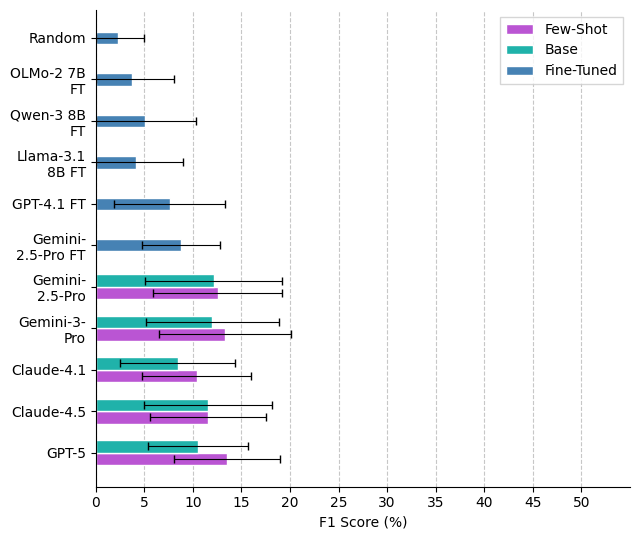

In [25]:
# API models that can have Base and Few-Shot
api_groups = [m for m in ['GPT-5', 
                          'Claude-4.5', 'Claude-4.1', 
                          'Gemini-3-Pro', 'Gemini-2.5-Pro',
                          ] if m in models]
base_idx = [models.index(m) for m in api_groups]

# Only plot Few-Shot where available
fs_avail = [m for m in api_groups if (m + ' FS') in models]
fs_idx   = [models.index(m + ' FS') for m in fs_avail]
# x-positions for FS should align with their Base counterpart
x_api = np.arange(len(api_groups))
x_fs  = np.array([api_groups.index(m) for m in fs_avail])

# Fine-tuned models (single condition)
ft_groups = [m for m in ['Gemini-2.5-Pro FT', 'GPT-4.1 FT',  'Llama-3.1 8B FT', 
                         'Qwen-3 8B FT', 'OLMo-2 7B FT', 'Random'] if m in models]
print(ft_groups)
ft_idx    = [models.index(m) for m in ft_groups]

# Values and 95% CI error bars
base_vals = [f1s[i] for i in base_idx]
base_errs = np.array([
    [f1s[i] - f1cils[i] for i in base_idx],
    [f1cius[i] - f1s[i] for i in base_idx],
])

fs_vals = [f1s[i] for i in fs_idx]
fs_errs = np.array([
    [f1s[i] - f1cils[i] for i in fs_idx],
    [f1cius[i] - f1s[i] for i in fs_idx],
])

ft_vals = [f1s[i] for i in ft_idx]
ft_errs = np.array([
    [f1s[i] - f1cils[i] for i in ft_idx],
    [f1cius[i] - f1s[i] for i in ft_idx],
])

# Layout (vertical chart using horizontal bars)
height = 0.3
gap    = 0  # visual gap between API and FT blocks
y_api  = np.arange(len(api_groups))
y_fs   = np.array([api_groups.index(m) for m in fs_avail])
y_ft   = np.arange(len(ft_groups)) + len(api_groups) + gap

fig, ax = plt.subplots(figsize=(6.5, 5.5))
err_style = dict(elinewidth=0.8, capsize=3, ecolor='k')
# Few-Shot bars (API subset)
if len(fs_vals) > 0:
    ax.barh(y_fs - height/2, fs_vals, height,
            label='Few-Shot', color='mediumorchid',
            xerr=fs_errs, error_kw=err_style, capsize=5, ecolor='k',
            edgecolor='white', linewidth=1)
ax.barh(y_api + height/2, base_vals, height,
        label='Base', color='lightseagreen',
        xerr=base_errs, error_kw=err_style, capsize=5, ecolor='k',
        edgecolor='white', linewidth=1)

# Fine-Tuned single bars
if len(ft_vals) > 0:
    ax.barh(y_ft, ft_vals, height,
            label='Fine-Tuned', color='steelblue',
            xerr=ft_errs, error_kw=err_style, capsize=5, ecolor='k',
            edgecolor='white', linewidth=1)

# Cosmetics
yticks = np.concatenate([y_api, y_ft])
ytick_labels = api_groups + ft_groups
ytick_labels = [textwrap.fill(lbl, width=10, break_long_words=True, break_on_hyphens=True)
                for lbl in ytick_labels]
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels)
ax.set_xlabel("F1 Score (%)")
# ax.set_xlim(0, 100)
# plt.xticks(np.arange(0, 105, 5))
ax.set_xlim(0, 55)
plt.xticks(np.arange(0, 55, 5))
ax.spines[['top', 'right']].set_visible(False)

ax.legend(ncols=1, fancybox=False, shadow=False, loc='upper right')
ax.set_axisbelow(True)
ax.grid(axis='x', which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.savefig("ft_prag_f1_score_comparison_vertical.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()